In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
import matplotlib.animation as animation
from matplotlib import cm

## WHAT'S GRADIENT DESCENT ALGORITHM?
Gradient Descent is the most common optimization algorithm in machine learning and deep learning. It is a first-order optimization algorithm which means it only takes into account the first derivative when performing the updates on the parameters.
On each and every iteration the paramteres are updated in the opposite direction of the gradient of the objective function .
The size of the step we take on each iteration to reach the local minimum is determined by the learning rate α. Therefore, we follow the direction of the slope downhill until we reach a local minimum.

In [3]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

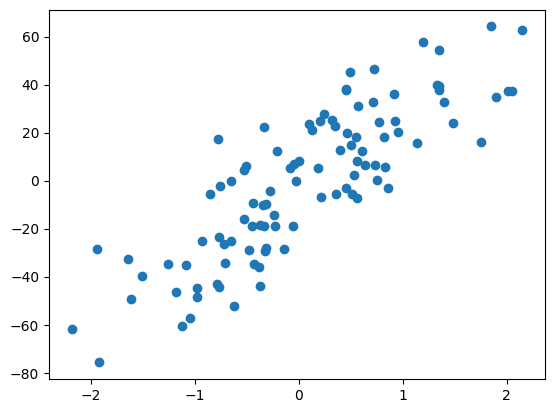

In [4]:
plt.scatter(X,y)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [9]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [10]:
class GDRegressor:

    def __init__(self, learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):

        # calculating b using GD regressor
        n = len(X)
        self.loss_hist = []

        for i in range(self.epochs):

            y_pred = self.m * X + self.b

            # compute loss
            loss = np.mean((y - y_pred) ** 2)

            # STORE LOSS
            self.loss_hist.append(loss)

            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b) * X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)

        print(self.m, self.b)

    def predict(self, X):
        return self.m * X + self.b

In [11]:
gd=GDRegressor(0.001,200)

In [12]:
gd.fit(X,y)

27.828091032520142 -2.2947445586769826


In [13]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6357827506345679

In [14]:
print("\n"*5)

## GRADIENT DESCENT 
## COST AND GRADIENTS 
<h4> The equation for calculating cost function and gradients are as shown below. 
   This particular cost function is for Linear regression and hence for other algorithms the cost function is different and hence different gradients would be derived from different cost functions.</h4>

<b>Cost</b>
\begin{equation}
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h(\theta)^{(i)} - y^{(i)})^2 
\end{equation}

<b>Gradient</b>

\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}(h(\theta^{(i)} - y^{(i)}).X_j^{(i)}
\end{equation}

<b>Gradients</b>
\begin{equation}
\theta_0: = \theta_0 -\alpha . (\frac{1}{m} .\sum_{i=1}^{m}(h(\theta^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}
\begin{equation}
\theta_1: = \theta_1 -\alpha . (\frac{1}{m} .\sum_{i=1}^{m}(h(\theta^{(i)} - y^{(i)}).X_1^{(i)})
\end{equation}
\begin{equation}
\theta_2: = \theta_2 -\alpha . (\frac{1}{m} .\sum_{i=1}^{m}(h(\theta^{(i)} - y^{(i)}).X_2^{(i)})
\end{equation}

\begin{equation}
\theta_j: = \theta_j -\alpha . (\frac{1}{m} .\sum_{i=1}^{m}(h(\theta^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}

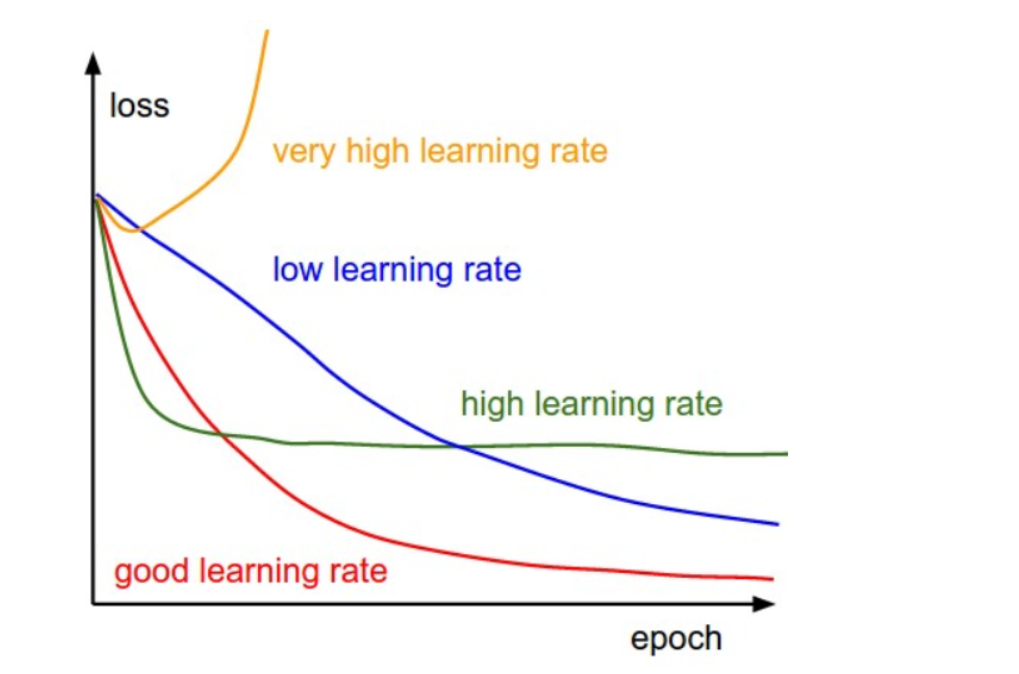

## GRADIENT DESCENT TRAINING LOSS CURVE 

**This plot shows how Mean-squared error(MSE) loss decreases during the training over each epoch.**

Each epoch updates the slope (m) and intercept (b) to minimize prediction error.

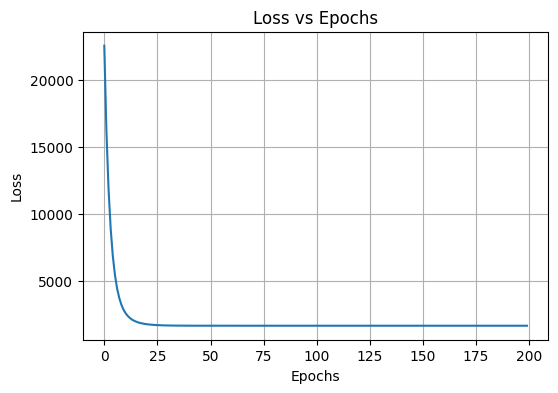

In [15]:
plt.figure(figsize=(6,4))
plt.plot(gd.loss_hist)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

## Key observations and insights 
->Loss decreases steadily which means our model is learning correctly

->Steep drop in early epochs depicts large gradient updates initially

->Gradual flattening : convergence toward optimal parameters

->Smooth curve shows stable learning rate

->No oscillation proves learning rate not too high

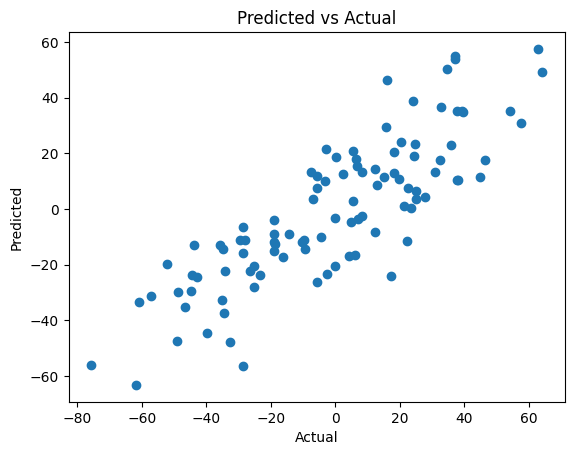

In [18]:
y_pred = gd.predict(X)

plt.scatter(y, y_pred)
plt.title("Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()